In [1]:
# Cell 1: Import libraries
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# Cell 2: Upload the dataset
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()


Saving drug200-1.csv to drug200-1.csv
Uploaded file: drug200-1.csv


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
# Cell 3: Basic data checks
print("DataFrame info:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all"))

print("\nMissing values per column:")
df.isnull().sum()


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB

Summary statistics:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,M,HIGH,HIGH,NaN,drugY
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN



Missing values per column:


,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [4]:
# Cell 4: Convert categoricals to numeric codes
mappings = {}

for col in ["Sex", "BP", "Cholesterol", "Drug"]:
    categories = sorted(df[col].unique())
    mapping = {category: idx for idx, category in enumerate(categories)}
    mappings[col] = mapping
    print(f"Mapping for {col}: {mapping}")
    df[col + "_num"] = df[col].map(mapping)

df[["Age", "Sex", "Sex_num", "BP", "BP_num",
    "Cholesterol", "Cholesterol_num", "Drug", "Drug_num"]].head()


Mapping for Sex: {'F': 0, 'M': 1}
Mapping for BP: {'HIGH': 0, 'LOW': 1, 'NORMAL': 2}
Mapping for Cholesterol: {'HIGH': 0, 'NORMAL': 1}
Mapping for Drug: {'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'drugY': 4}


,Age,Sex,Sex_num,BP,BP_num,Cholesterol,Cholesterol_num,Drug,Drug_num
0,23,F,0,HIGH,0,HIGH,0,drugY,4
1,47,M,1,LOW,1,HIGH,0,drugC,2
2,47,M,1,LOW,1,HIGH,0,drugC,2
3,28,F,0,NORMAL,2,HIGH,0,drugX,3
4,61,F,0,LOW,1,HIGH,0,drugY,4


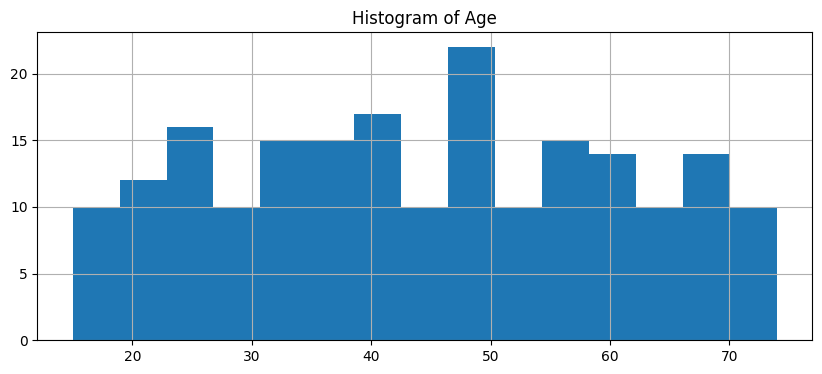

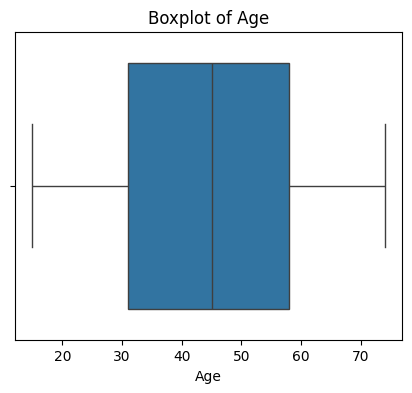

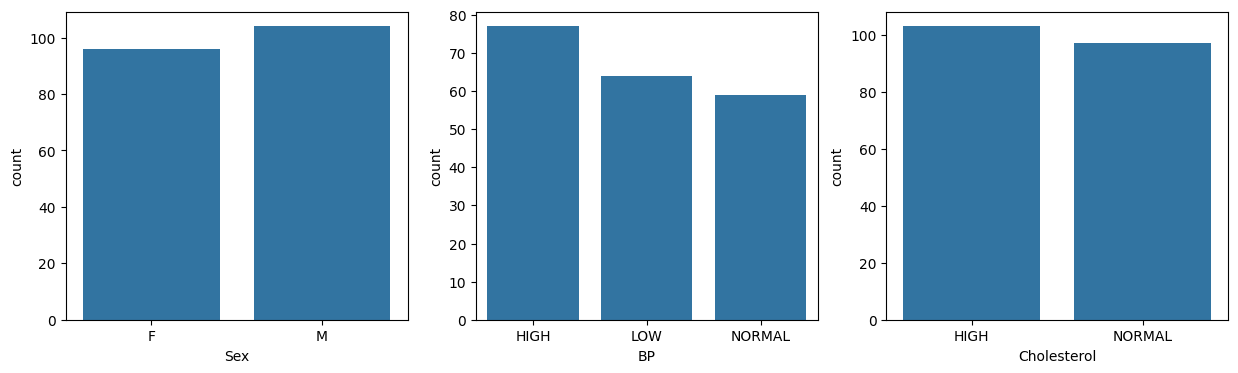

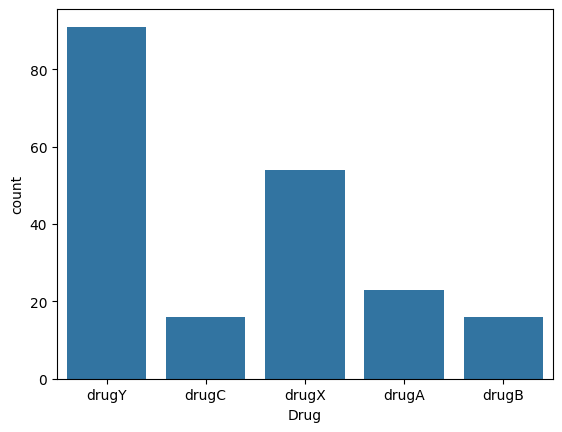

In [5]:
# Histogram and boxplot for Age
plt.figure(figsize=(10,4))
df["Age"].hist(bins=15)
plt.title("Histogram of Age")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(x=df["Age"])
plt.title("Boxplot of Age")
plt.show()

# Bar plots
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(ax=axes[0], x="Sex", data=df)
sns.countplot(ax=axes[1], x="BP", data=df)
sns.countplot(ax=axes[2], x="Cholesterol", data=df)
plt.show()

sns.countplot(x="Drug", data=df)
plt.show()


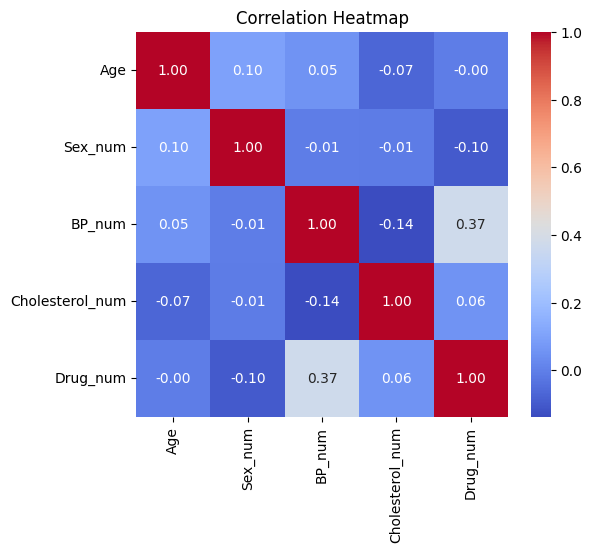

In [6]:
corr_cols = ["Age", "Sex_num", "BP_num", "Cholesterol_num", "Drug_num"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [7]:
feature_cols = ["Age", "Sex_num", "BP_num", "Cholesterol_num"]
target_col = "Drug_num"

X = df[feature_cols].values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]


array([[ 0.80560431, -1.01438923,  0.06917145, -0.98581488],
       [-0.51491792, -1.01438923, -1.14132887, -0.98581488],
       [ 1.46586543, -1.01438923,  1.27967176, -0.98581488],
       [ 1.70596038,  0.98581488, -1.14132887, -0.98581488],
       [ 0.80560431,  0.98581488, -1.14132887, -0.98581488]])

In [8]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_scaled, y_train)

y_pred_dt = dt_clf.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.55
[[ 4  0  0  0  3]
 [ 1  3  0  0  1]
 [ 0  0  5  0  0]
 [ 0  0  0  8  8]
 [ 5  1  4  4 13]]
              precision    recall  f1-score   support

           0       0.40      0.57      0.47         7
           1       0.75      0.60      0.67         5
           2       0.56      1.00      0.71         5
           3       0.67      0.50      0.57        16
           4       0.52      0.48      0.50        27

    accuracy                           0.55        60
   macro avg       0.58      0.63      0.58        60
weighted avg       0.57      0.55      0.55        60



In [9]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.6
[[ 4  0  0  0  3]
 [ 1  3  0  0  1]
 [ 0  0  5  0  0]
 [ 0  0  0 11  5]
 [ 5  1  3  5 13]]
              precision    recall  f1-score   support

           0       0.40      0.57      0.47         7
           1       0.75      0.60      0.67         5
           2       0.62      1.00      0.77         5
           3       0.69      0.69      0.69        16
           4       0.59      0.48      0.53        27

    accuracy                           0.60        60
   macro avg       0.61      0.67      0.62        60
weighted avg       0.61      0.60      0.60        60



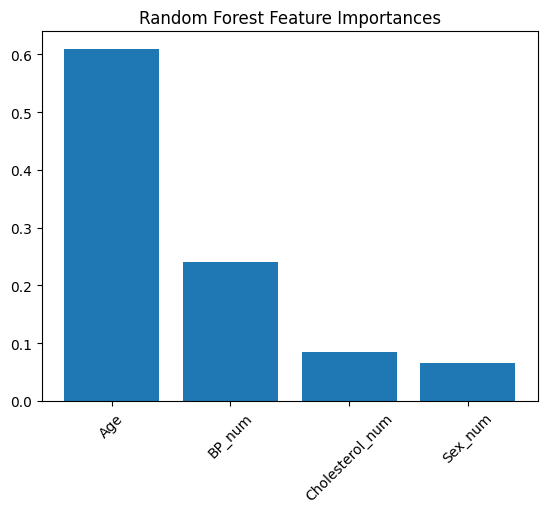

In [10]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.bar(range(len(feature_cols)), importances[indices])
plt.xticks(range(len(feature_cols)), np.array(feature_cols)[indices], rotation=45)
plt.title("Random Forest Feature Importances")
plt.show()


In [11]:
print(
"The model learns patterns that connect Age, Sex, Blood Pressure, and Cholesterol "
"to the type of drug a patient is prescribed. Each decision tree applies simple "
"if-then rules, and the random forest combines many trees to produce more stable predictions."
)


The model learns patterns that connect Age, Sex, Blood Pressure, and Cholesterol to the type of drug a patient is prescribed. Each decision tree applies simple if-then rules, and the random forest combines many trees to produce more stable predictions.
